# ASNA 2026 GLP-1 Effects Graphs
The following data are from the Test Set. 

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.width', 1000)


train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train['Death Flag'].value_counts(normalize = True))

print(train.isnull().sum())


Death Flag
0    0.9838
1    0.0162
Name: proportion, dtype: float64
ID                            0
Age                           0
Sex                           0
Smoker Status                 0
BMI                           0
Health Status                 0
GLP-1                         0
GLP-1 Duration in Years    7688
Province                      0
Face Amount                   0
Death Flag                    0
dtype: int64


Note that value_counts gives the porpotions of the death flags. Also we can do some data cleaning with the GLP-1 Duration in Years Section. 

With that in mind, Data Clean Time!
 

In [101]:
def clean(df):
    df = df.copy()
    df.columns = df.columns.str.strip()

    # GLP-1
    df['GLP-1 Duration in Years'] = df['GLP-1 Duration in Years'].fillna(0)

    #Statuses
    df['Health Status'] = df['Health Status'].map({'Poor' : 4, 'Fair': 3, 'Good': 2, 'Excellent': 1})
    df['Smoker Status'] = df['Smoker Status'].map({'No': 0, 'Yes': 1})

    return df
    
clean_train = clean(train)
clean_test = clean(test)

print(clean_train.head(n = 6))
print(clean_test.head(n = 6))

   ID  Age Sex  Smoker Status   BMI  Health Status  GLP-1  GLP-1 Duration in Years          Province Face Amount  Death Flag
0   1   56   F              0  28.5              2      0                      0.0            Quebec   $750,000            0
1   2   50   F              0  26.7              2      1                      3.2          Manitoba   $250,000            0
2   3   27   F              1  33.1              2      1                      0.0           Ontario   $250,000            0
3   4   47   F              0  36.9              3      0                      0.0            Quebec   $500,000            0
4   5   56   F              0  25.7              2      0                      0.0           Ontario   $100,000            0
5   6   30   M              0  25.6              1      0                      0.0  British Columbia   $500,000            0
      ID  Age Sex  Smoker Status   BMI  Health Status  GLP-1  GLP-1 Duration in Years          Province   Face Amount   Usage

As we have done data cleaning, lets visualize some data
##  Death Flag Distribtuion



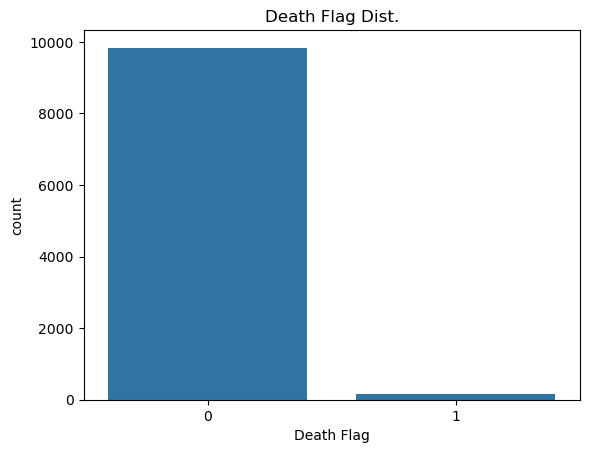

np.int64(162)

In [109]:
sns.countplot(x= 'Death Flag', data = train)
plt.title('Death Flag Dist.')
plt.show()

(train['Death Flag'] == 1).sum()

Oh chungus, we only got 162 pos. cases. We are screwed.

# Death Flag VS Age, Death Flag VS BMI, Death Flag VS GLP Duration in Years

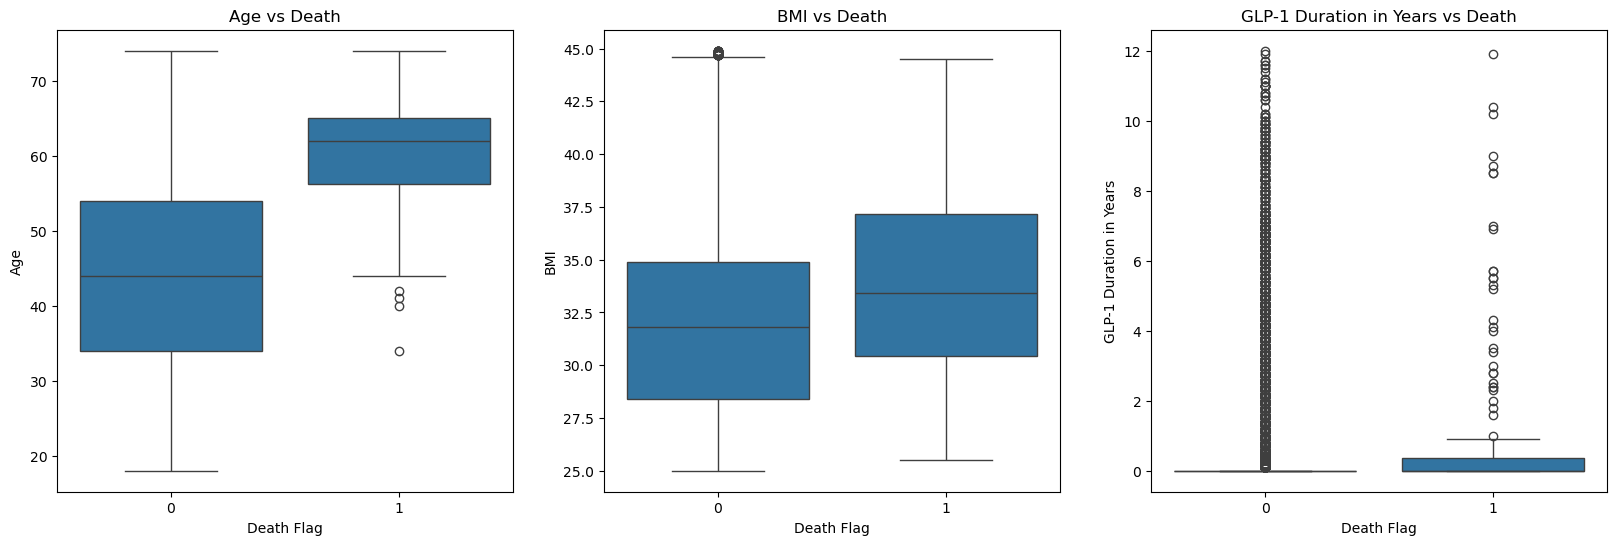

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(x='Death Flag', y='Age', data= clean_train, ax = axes[0])
axes[0].set_title('Age vs Death')

sns.boxplot(x='Death Flag', y='BMI', data= clean_train, ax = axes[1])
axes[1].set_title('BMI vs Death')


sns.boxplot(x='Death Flag', y='GLP-1 Duration in Years', data= clean_train, ax = axes[2])
axes[2].set_title('GLP-1 Duration in Years vs Death')

plt.show()

As we have done some comparison of numerical data and death flag. Now lets do some categorical data.

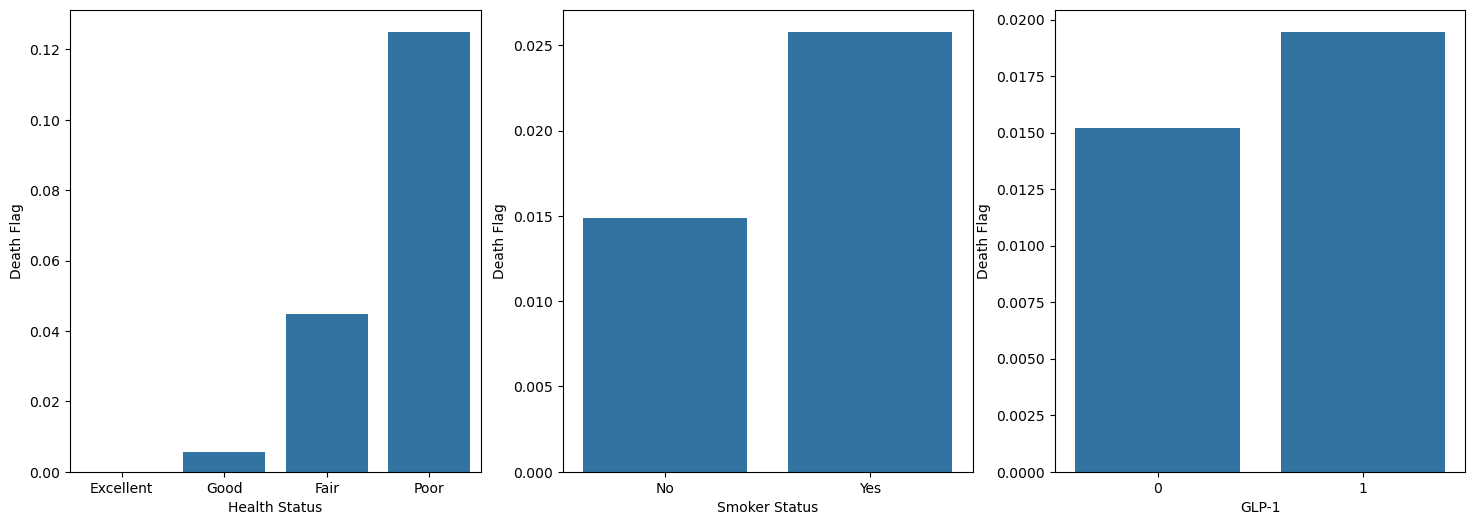

In [104]:
fig, axes = plt.subplots(1, 3, figsize = (18,6))

sns.barplot(x = 'Health Status', y = 'Death Flag', data = health_rate, ax = axes[0], errorbar = None
           , order = ['Excellent', 'Good', 'Fair', 'Poor'])
sns.barplot(x = 'Smoker Status', y = 'Death Flag', data = train, ax = axes[1], errorbar = None)
sns.barplot(x = 'GLP-1', y = 'Death Flag', data = train, ax = axes[2], errorbar = None) 

plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

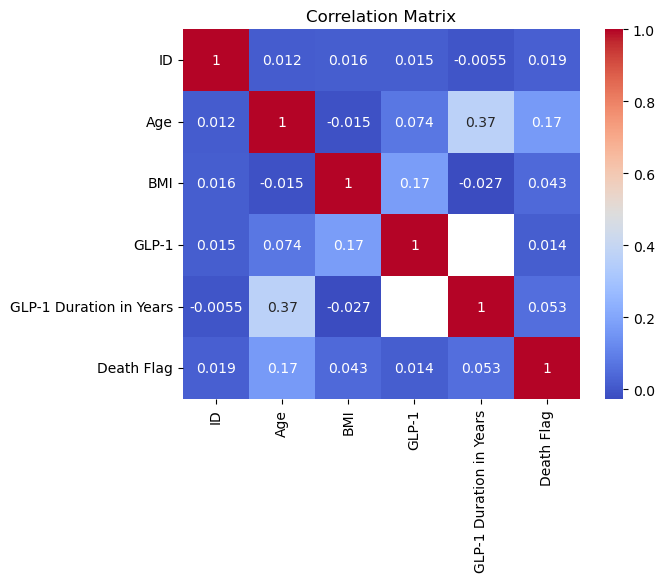

In [105]:
corr_mtrx = train.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_mtrx, annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrix')

The above correlation matrix is cool. (I don't usually laugh at my puns:))

Now let's make some risk factors that will aid our tree search

In [106]:
train_fe = clean_train.copy()
test_fe = clean_test.copy()

for df in [train_fe, test_fe]:
    df['Age_BMI'] = df['Age'] * df['BMI']
    df['Age_Health'] = df['Age'] * df['Health Status']
    df['Smoker_Age'] = df['Age'] * df['Smoker Status']

    # GLP-1 interations
    # Duration per year of age
    df['GLP-1_Duration Age'] = df['GLP-1 Duration in Years'] / (df['Age'])
    df['GLP1_Active'] = ((df['GLP-1'] == 1) & (df['GLP-1 Duration in Years'] > 0))

train_fe.head(n=10)
# train_fe.head(n=10)

,ID,Age,Sex,Smoker Status,BMI,Health Status,GLP-1,GLP-1 Duration in Years,Province,Face Amount,Death Flag,Age_BMI,Age_Health,Smoker_Age,GLP-1_Duration Age,GLP1_Active
0,1,56,F,0,28.5,2,0,0.0,Quebec,"$750,000",0,1596.0,112,0,0.000000,False
1,2,50,F,0,26.7,2,1,3.2,Manitoba,"$250,000",0,1335.0,100,0,0.064000,True
2,3,27,F,1,33.1,2,1,0.0,Ontario,"$250,000",0,893.7,54,27,0.000000,False
3,4,47,F,0,36.9,3,0,0.0,Quebec,"$500,000",0,1734.3,141,0,0.000000,False
4,5,56,F,0,25.7,2,0,0.0,Ontario,"$100,000",0,1439.2,112,0,0.000000,False
5,6,30,M,0,25.6,1,0,0.0,British Columbia,"$500,000",0,768.0,30,0,0.000000,False
6,7,18,F,0,26.0,1,0,0.0,Quebec,"$250,000",0,468.0,18,0,0.000000,False
7,8,45,M,0,26.2,2,0,0.0,British Columbia,"$500,000",0,1179.0,90,0,0.000000,False
8,9,35,F,0,29.5,2,0,0.0,Ontario,"$750,000",0,1032.5,70,0,0.000000,False
9,10,53,F,0,33.8,2,1,6.7,Alberta,"$250,000",0,1791.4,106,0,0.126415,True


## Remarks:
- Higher Age_BMI factor typically leads to a higher death count
- Higher Age_Health factor typically leads to higher death count

Cool lets rock and roll

In [110]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 50.9 MB/s  0:00:00


In [113]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

StratifiedKFold(n_splits=5, shuffle=True)

StratifiedKFold(n_splits=5, random_state=None, shuffle=True)